Name :- Abhijeet Dinakar Pathade

Roll_No :- 16

Division :- A

**Train and save the model**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from mpl_toolkits.mplot3d import Axes3D

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Read the Advertising dataset
df = pd.read_csv("/content/drive/MyDrive/Advertising.csv")


In [4]:
df.shape

(200, 3)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Newspaper  200 non-null    float64
 2   Sales      200 non-null    float64
dtypes: float64(3)
memory usage: 4.8 KB


In [6]:
df.head()

,TV,Newspaper,Sales
0,230.1,69.2,22.1
1,44.5,45.1,10.4
2,17.2,69.3,9.3
3,151.5,58.5,18.5
4,180.8,58.4,12.9


In [7]:
df.describe()

,TV,Newspaper,Sales
count,200.000000,200.000000,200.000000
mean,147.042500,30.554000,14.022500
std,85.854236,21.778621,5.217457
min,0.700000,0.300000,1.600000
25%,74.375000,12.750000,10.375000
50%,149.750000,25.750000,12.900000
75%,218.825000,45.100000,17.400000
max,296.400000,114.000000,27.000000


In [8]:
# Define features (X) and target (y)
X = df[['TV', 'Newspaper']]   # independent variables
y = df['Sales']           # dependent variable


In [9]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
#Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [11]:
#Predictions
y_pred = model.predict(X_test)

In [12]:
#Evaluation
print("Coefficients (slopes):", model.coef_)
print("Intercept:", model.intercept_)
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

Coefficients (slopes): [0.04627186 0.05609097]
Intercept: 5.478645182721355
Mean Squared Error (MSE): 11.062557300662816
R² Score: 0.6495152805385851


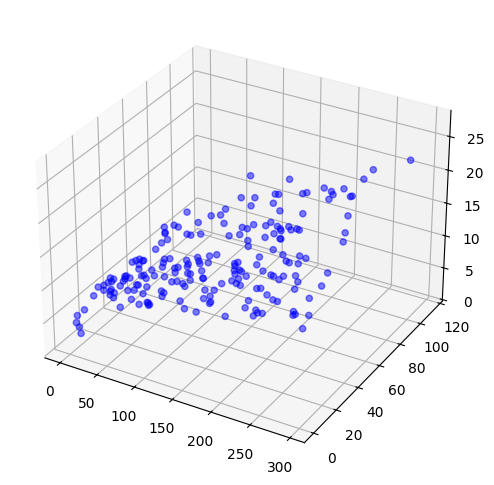

In [13]:
# Visualisation (3D Scatter + Regression Plane)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X['TV'], X['Newspaper'], y, c='blue', marker='o', alpha=0.5, label="Actual")


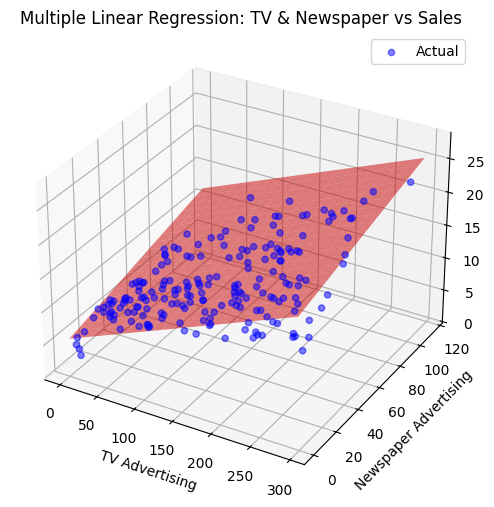

In [14]:
# Visualisation (3D Scatter + Regression Plane)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X['TV'], X['Newspaper'], y, c='blue', marker='o', alpha=0.5, label="Actual")

# Create meshgrid for regression plane
tv_range = np.linspace(X['TV'].min(), X['TV'].max(), 20)
Newspaper_range = np.linspace(X['Newspaper'].min(), X['Newspaper'].max(), 20)
tv_grid, Newspaper_grid = np.meshgrid(tv_range, Newspaper_range)
sales_pred = model.intercept_ + model.coef_[0]*tv_grid + model.coef_[1]*Newspaper_grid

ax.plot_surface(tv_grid, Newspaper_grid, sales_pred, color='red', alpha=0.5)

ax.set_xlabel('TV Advertising')
ax.set_ylabel('Newspaper Advertising')
ax.set_zlabel('Sales')
ax.set_title("Multiple Linear Regression: TV & Newspaper vs Sales")
plt.legend()
plt.show()


In [15]:
# Prediction for a new advertising plan
new_advertising = np.array([[150, 30]])  # example (TV advertising=150, Newspaper advertising=30)
predicted_sales = model.predict(new_advertising)
print("Predicted Sales for TV=150 and Newspaper=30:", predicted_sales[0])


Predicted Sales for TV=150 and Newspaper=30: 14.102153429465126


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [16]:
import pickle

In [17]:
pickle.dump(model,open('MLRModel.pkl','wb'))

**Flask Code**

In [18]:
from flask import Flask, render_template, request
import pickle
import numpy as np

app = Flask(__name__)

# Load the trained Multiple Linear Regression model
model = pickle.load(open("MLRModel.pkl", "rb"))


@app.route('/')
def home():
    return render_template("index.html")


@app.route('/predict', methods=['POST'])
def predict():

    # Read inputs from the HTML form
    tv = float(request.form['tv'])
    Newspaper = float(request.form['Newspaper'])

    # Predict sales
    prediction = model.predict(np.array([[tv, Newspaper]]))

    return render_template(
        "index.html",
        prediction_text=f"Predicted Sales : {prediction[0]:.2f}"
    )


if __name__ == "__main__":
    app.run(debug=True)


 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


**HTML Code**

In [19]:
<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Sales Predictor</title>

    <style>

        *{
            margin:0;
            padding:0;
            box-sizing:border-box;
            font-family:Arial, Helvetica, sans-serif;
        }

        body{

            background:#f4f7fc;
            display:flex;
            justify-content:center;
            align-items:center;
            height:100vh;

        }

        .container{

            width:430px;
            background:white;
            padding:35px;
            border-radius:15px;
            box-shadow:0 10px 25px rgba(0,0,0,.2);

        }

        h1{

            text-align:center;
            color:#0d47a1;
            margin-bottom:8px;

        }

        h3{

            text-align:center;
            color:#555;
            margin-bottom:25px;

        }

        label{

            font-weight:bold;
            display:block;
            margin-top:12px;
            margin-bottom:6px;

        }

        input{

            width:100%;
            padding:12px;
            border:1px solid #ccc;
            border-radius:8px;
            font-size:16px;

        }

        button{

            width:100%;
            margin-top:25px;
            padding:12px;
            font-size:18px;
            background:#1565c0;
            color:white;
            border:none;
            border-radius:8px;
            cursor:pointer;
            transition:.3s;

        }

        button:hover{

            background:#0d47a1;

        }

        .result{

            margin-top:25px;
            background:#e8f5e9;
            color:green;
            padding:15px;
            border-radius:8px;
            text-align:center;
            font-size:20px;
            font-weight:bold;

        }

        footer{

            text-align:center;
            margin-top:20px;
            color:#777;
            font-size:13px;

        }

    </style>

</head>

<body>

<div class="container">

    <h1>Sales Predictor</h1>

    <h3>Multiple Linear Regression</h3>

    <form action="/predict" method="POST">

        <label>Enter TV Advertising</label>

        <input
            type="number"
            name="tv"
            step="0.01"
            min="0"
            placeholder="Example : 150"
            required>

        <label>Enter Newspaper Advertising</label>

        <input
            type="number"
            name="Newspaper"
            placeholder="Example : 30"
            required>

        <button type="submit">

            Predict Sales

        </button>

    </form>

    {% if prediction_text %}

    <div class="result">

        {{ prediction_text }}

    </div>

    {% endif %}

    <footer>

        Machine Learning by Dr. Sachin Balawant Takmare

    </footer>

</div>

</body>
</html>

SyntaxError: invalid decimal literal (3125258297.py, line 26)